# **LAB 03**

## **Esercizio 3.1**
#### INTRODUZIONE
In questo esercizio si affronta il problema della valutazione di opzioni finanziarie di tipo europeo: si tratta di un contratto che conferisce al titolare il diritto (ma non l’obbligo) di comprare o vendere un'attività a un prezzo fissato (*strike price*), a una certa data futura (*scadenza*). In particolare, si distinguono: 
- **Call option**: diritto di acquistare l’asset a prezzo $K$
- **Put option**: diritto di vendere l’asset a prezzo $K$

Il modello di riferimento per determinare il prezzo è il Black–Scholes, che descrive l’evoluzione del prezzo di un asset sottostante $S(t)$ come un Moto Browniano Geometrico (GBM): si tratta di un modello matematico usato per descrivere l’evoluzione nel tempo di grandezze che sono soggette sia a una crescita deterministica sia a una componente casuale. Questo modello assume che i rendimenti siano gaussiani, la volatilità $\sigma$ (che descrive quanto un prezzo oscilla) sia costante e il drift medio (ovvero la crescita media attesa del prezzo) ia costante e pari al tasso privo di rischio $r$. 

L'evoluzione temporale è descritta dall'equazione stocastica: 
$$ dS(t)=rS(t)dt + \sigma S(t) dW(t) $$
la cui soluzione analitica è: 
$$S(t) = S(0) \exp{\left [ \left ( r -\frac{1}{2} \sigma^2 \right )r + \sigma W(t) \right ]}$$
dove $W(t)$ è un moto browniano standard. 

Il valore di un’opzione non è semplicemente il payoff finale, ma il valore atteso scontato al presente:
$$ C(0) = e^{-rT} \, \text{max}(S(T)-K,0) $$
$$ P(0) = e^{-rT} \, \text{max}(K-S(T),0) $$
dove il fattore $e^{-rT}$ rappresenta lo sconto al tempo presente secondo il tasso di interesse privo di rischio $r$. 

#### SOLUZIONE ANALITICA
Nel caso del GBM con parametri costanti, il problema ammette una soluzione analitica chiusa: 
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

dove: 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right] \qquad d_2 = d_1 - \sigma\sqrt{T-t}$$


e dove $N(x)$ è la funzione cumulativa della distribuzione normale standard. 

#### METODO MONTECARLO
Quando invece la soluzione analitica non è disponibile, si può stimare il presso tramite simulazione Monte Carlo. L'idea geneale è quella di generale molte realizzazioni del prezzo finale $S(T)$, calcolare il payoff per ogni realizzazione, fare la media e scontare al tempo presente. Dunque, 

$$ C(0) \approx e^{-rT} \frac{1}{N} \sum_{i=1}^N \text{max}(S_T^{i}-K,0) $$

In questo esercizio vengono implementati due metodi equivalenti: 
- **Sampling diretto**: si genera direttamente $S(T)$ come

  $$S(T) = S(0) \exp{\left [ \left ( r -\frac{1}{2} \sigma^2 \right )r + \sigma z \sqrt{T} \right ]} $$

  con $z$ numero casuale tra 0 e 1.
- **Sampling discretizzato**: si ricostruisce l’intero percorso del prezzo dividendo $[0,T]$ in 100 intervalli temporali $S_0, S_1, \dots S_{100}$ usando la discretizzazione

$$S_{i+1}(T) = S_i \exp{\left [ \left ( r -\frac{1}{2} \sigma^2 \right )r + \sigma z_i \sqrt{\Delta t} \right ]} $$


I parametri utilizzati sono i seguenti: 
- $S(0) = 100$
- $K = 100$
- $T=1$
- $r = 0.1$
- $\sigma =0.025$

In entrambi i casi, per migliorare la stima numerica, si utilizza il metodo del data blocking con $10^5$ simulazioni divisi in 150 blocchi. 

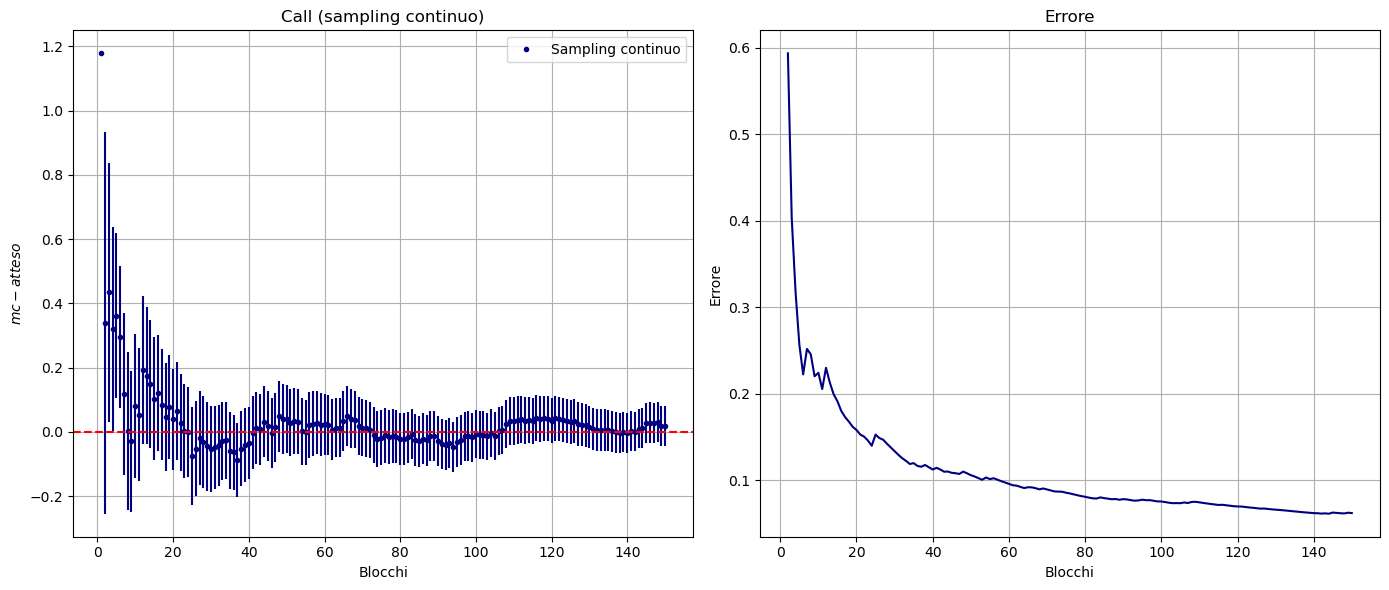

In [4]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt("data_c.dat")
data_atteso= np.loadtxt("data_atteso.dat")
c_atteso = data_atteso[0]
p_atteso = data_atteso[1]
x=data[:,0]
y=data[:,1]-c_atteso
error=data[:,2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x,y, ".", color ='navy', label = 'Sampling continuo')
axes[0].errorbar(x,y,yerr=error, color="navy", linestyle="none")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("$mc-atteso$")
axes[0].set_title("Call (sampling continuo)")
axes[0].grid(True)
axes[0].legend(); 

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='navy',)
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()



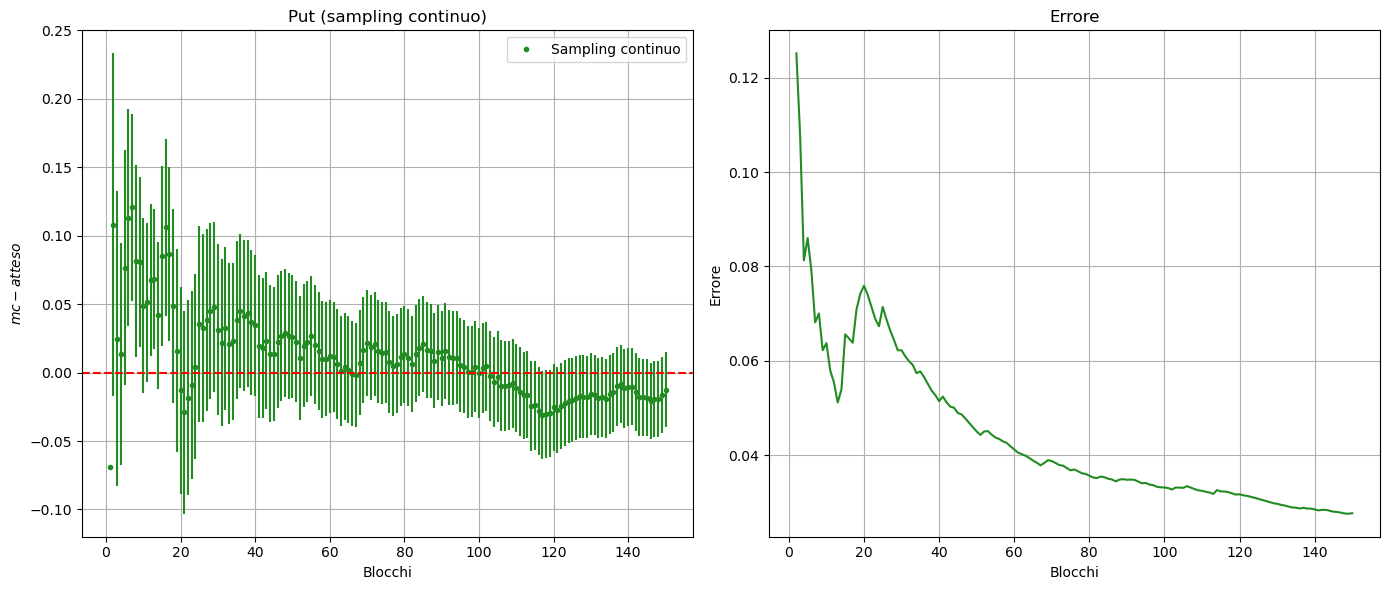

In [3]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt("data_p.dat")
data_atteso= np.loadtxt("data_atteso.dat")
c_atteso = data_atteso[0]
p_atteso = data_atteso[1]
x=data[:,0]
y=data[:,1]-p_atteso
error=data[:,2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x,y, ".", color ='forestgreen', label = 'Sampling continuo')
axes[0].errorbar(x,y,yerr=error, color="forestgreen", linestyle="none")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("$mc-atteso$")
axes[0].set_title("Put (sampling continuo)")
axes[0].grid(True)
axes[0].legend(); 

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='forestgreen',)
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()

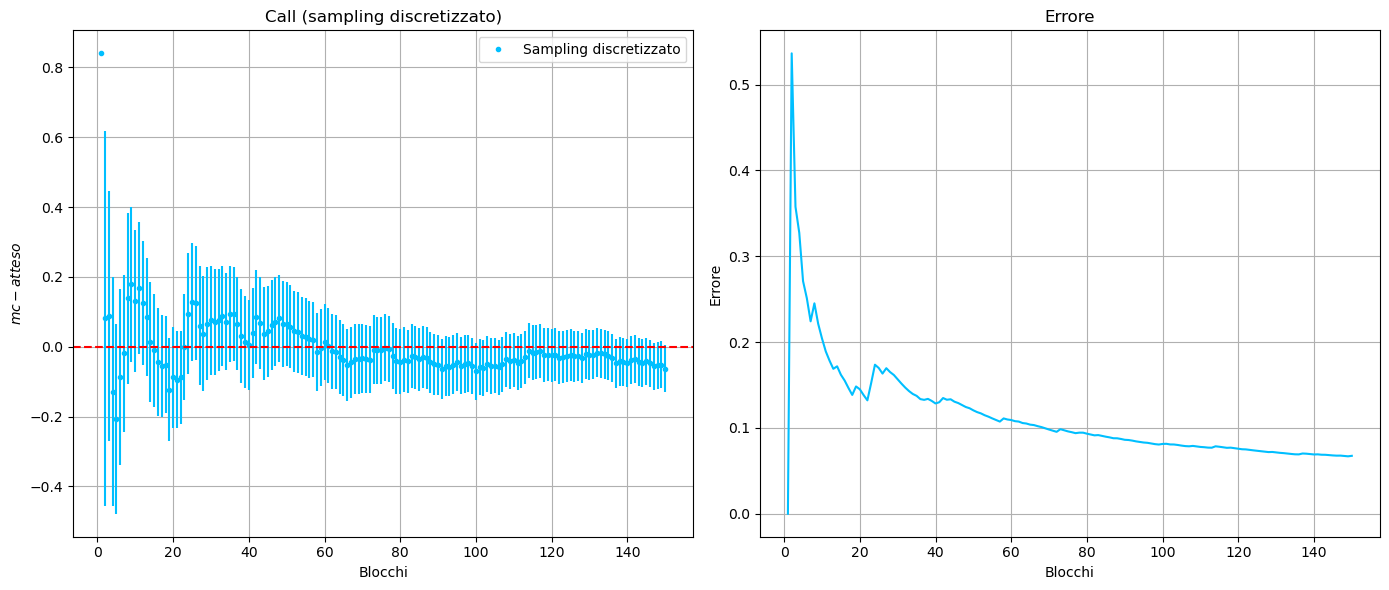

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("data_c_dis.dat")
data_atteso= np.loadtxt("data_atteso.dat")
c_atteso = data_atteso[0]
p_atteso = data_atteso[1]
x=data[:,0]
y=data[:,1]-c_atteso
error=data[:,2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x,y, ".", color ='deepskyblue', label = 'Sampling discretizzato')
axes[0].errorbar(x,y,yerr=error, color="deepskyblue", linestyle="none")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("$mc-atteso$")
axes[0].set_title("Call (sampling discretizzato)")
axes[0].grid(True)
axes[0].legend(); 

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='deepskyblue',)
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()



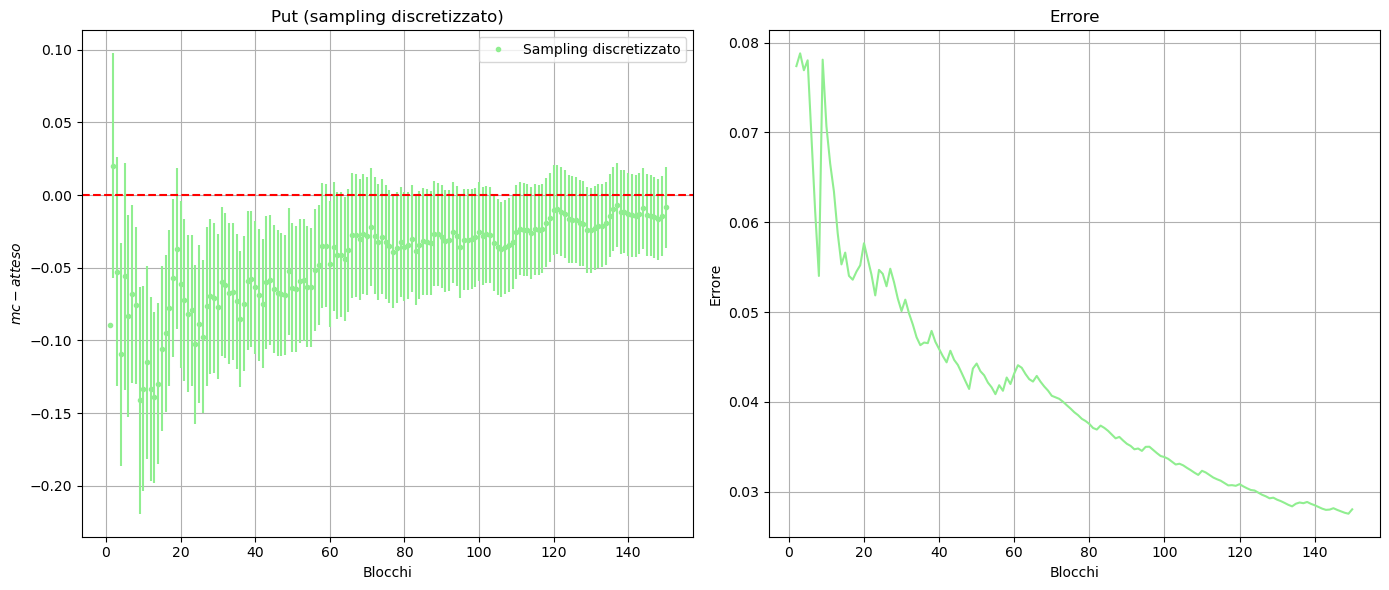

In [5]:
import numpy as np
import matplotlib.pyplot as plt


data = np.loadtxt("data_p_dis.dat")
data_atteso= np.loadtxt("data_atteso.dat")
c_atteso = data_atteso[0]
p_atteso = data_atteso[1]
x=data[:,0]
y=data[:,1]-p_atteso
error=data[:,2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PLOT VALOR MEDIO
axes[0].plot(x,y, ".", color ='lightgreen', label = 'Sampling discretizzato')
axes[0].errorbar(x,y,yerr=error, color="lightgreen", linestyle="none")
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel("Blocchi")
axes[0].set_ylabel("$mc-atteso$")
axes[0].set_title("Put (sampling discretizzato)")
axes[0].grid(True)
axes[0].legend(); 

# PLOT ERRORE
axes[1].errorbar(x, error, marker='', linestyle='-', color='lightgreen',)
axes[1].set_xlabel("Blocchi")
axes[1].set_ylabel("Errore")
axes[1].set_title("Errore")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## ANALISI DEI DATI
In entrambe le analisi condotte per tutti i risultati si riscontra un buon accordo con quanto atteso e anche confrontando l'andamento degli errori rispetto ai blocchi non ci sono evidenti incongruenze. Come atteso, non risulta esserci un metodo marcatamente privilegiato per condurre l'analisi: le piccole differenze tra i due metodi sono da ritenersi di natura statistica.